## 18.2. Gaussian Process Priors (GPs)

In [1]:
import numpy as np
from scipy.spatial import distance_matrix
from d2l import torch as d2l

d2l.set_figsize()

### 18.2.1 Definition

$$
f(x) = w^⊤ϕ(x) = ⟨w, ϕ(x)⟩
$$

### 18.2.2. A Simple Gussian Process

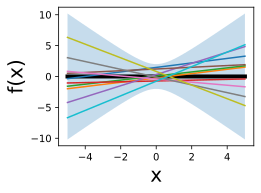

In [3]:
def lin_func(x, n_sample):
  preds = np.zeros((n_sample, x.shape[0]))
  for ii in range(n_sample):
    w = np.random.normal(0, 1, 2)
    y = w[0] + w[1] * x
    preds[ii, :] = y
  return preds

x_points = np.linspace(-5, 5, 50)
outs = lin_func(x_points, 10)
lw_bd = -2 * np.sqrt((1 + x_points ** 2))
up_bd = 2 * np.sqrt((1 + x_points ** 2))

d2l.plt.fill_between(x_points, lw_bd, up_bd, alpha=0.25)
d2l.plt.plot(x_points, np.zeros(len(x_points)), linewidth=4, color='black')
d2l.plt.plot(x_points, outs.T)
d2l.plt.xlabel("x", fontsize=20)
d2l.plt.ylabel("f(x)", fontsize=20)
d2l.plt.show()

### 18.2.3 From Weight Space to Function Space

$$
m(x) = E[f(x)] = E[w_0 + w_1 x] = E[w_0] + E[w_1]x = 0 + 0 = 0
$$

$$
k(x, x') = \text{Cov}(f(x), f(x')) = E[f(x)f(x')] - E[f(x)]E[f(x')] = E[w_0^2 + w_1w_0x + w_1^2xx'] = 1
$$

### 18.2.4. The Radial Basis Function (RBF) Kernel

$$
f(x) = \sum_{i=1}^Jw_iϕ_i(x), w_i ∼ \mathcal{N}(0, \frac{σ^2}J), ϕ_i(x) = \exp(-\frac{(x - c_i)^2}{2ℓ^2})
$$

$$
k(x, x') = \frac{σ^2}{J}\sum_{i=1}^Jϕ_i(x)ϕ_i(x')
$$

$$
k(x, x') = ∫_{-\infin}^\infin \exp(-\frac{(x - c)^2}{2ℓ^2})\exp(-\frac{(x' - c)^2}{2ℓ^2})dc = \sqrt{π}ℓσ^2\exp(-\frac{(x - x')^2}{2(\sqrt{2}ℓ)^2}) ∝ k_{RBF}(x, x')
$$

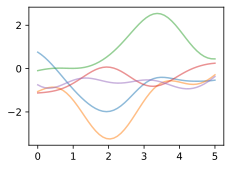

In [4]:
def rbfkernel(x1, x2, ls=4.): #@save
  dist = distance_matrix(np.expand_dims(x1, 1), np.expand_dims(x2, 1))
  return np.exp(-(1. / ls / 2) * (dist ** 2))

x_points = np.linspace(0, 5, 50)
meanvec = np.zeros(len(x_points))
covmat = rbfkernel(x_points, x_points, 1)

prior_samples = np.random.multivariate_normal(meanvec, covmat, size=5)
d2l.plt.plot(x_points, prior_samples.T, alpha=0.5)
d2l.plt.show()

### 18.2.5. The Neural Network Kernel

$$
f(x) = b + \sum_{i=1}^Jv_ih(x; u_i)
$$

$$
m(x) = E[f(x)] = 0
$$

$$
k(x, x') = \text{cov}[f(x), f(x')] = E[f(x)f(x')] = σ_b^2 + \frac1J\sum_{i=1}^Jσ_v^2E[h_i(x; u_i)h_i(x';u_i)]
$$